In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

Successfully loaded dataset with 224 rows.



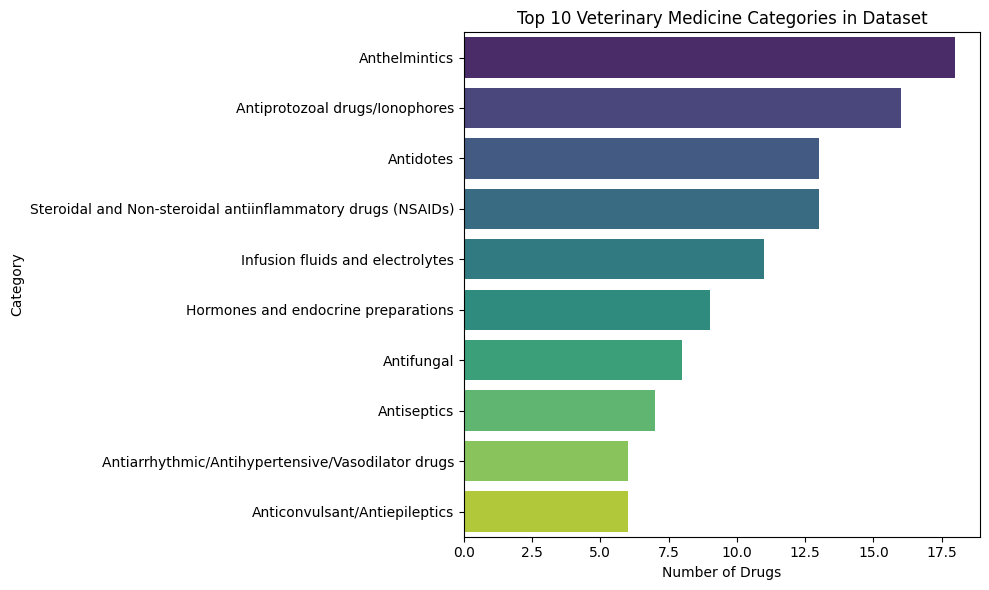

In [ ]:
def load_and_clean_data(csv_path):
    try:
        df = pd.read_csv(csv_path)
        print(f"Successfully loaded dataset with {df.shape[0]} rows.\n")
    except FileNotFoundError:
        print("Error: Could not find the CSV file. Please upload it to the Colab files panel.")
        return None

    # Handle missing values and strip whitespace
    df['category'] = df['category'].fillna('').astype(str).str.strip()
    df['indications'] = df['indications'].fillna('').astype(str).str.strip()
    df['generic_name'] = df['generic_name'].fillna('').astype(str).str.strip()

    # Combine fields to build the text profile for the engine
    df['metadata'] = df['category'] + " " + df['indications']

    # Graph tof top 10 categories
    plt.figure(figsize=(10, 6))
    top_categories = df['category'].value_counts().head(10)
    sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette='viridis', legend=False)
    plt.title('Top 10 Veterinary Medicine Categories in Dataset')
    plt.xlabel('Number of Drugs')
    plt.ylabel('Category')
    plt.tight_layout()
    plt.show()

    return df

# Initialize
csv_filename = 'national_essential_veterinary_medicine_list_2023.csv'
df = load_and_clean_data(csv_filename)

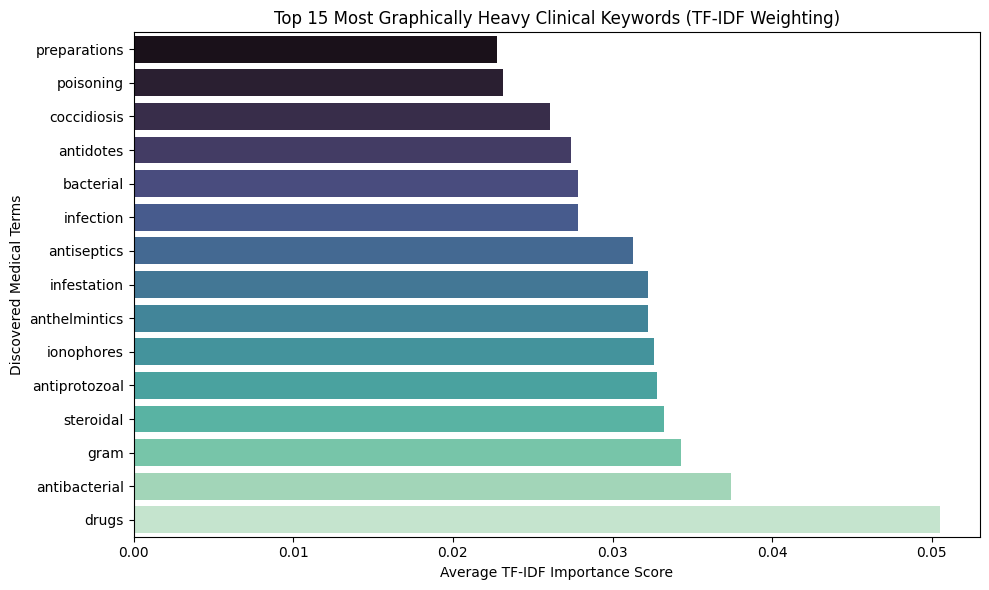


Matrix Setup Complete: 224 drugs mapped against 350 unique vocabulary dimensions.


In [ ]:
# 1. Initialize the vectorizer and strip common english stop words
tfidf = TfidfVectorizer(stop_words='english')

# 2. Fit and transform the text data into a numerical matrix
tfidf_matrix = tfidf.fit_transform(df['metadata'])
feature_names = tfidf.get_feature_names_out()

# 3. Calculate average weights to visualize important medical terms
avg_scores = np.mean(tfidf_matrix.toarray(), axis=0)
top_indices = np.argsort(avg_scores)[-15:]
top_words = [feature_names[i] for i in top_indices]
top_word_scores = [avg_scores[i] for i in top_indices]

# 4. Plot the keyword weights
plt.figure(figsize=(10, 6))
sns.barplot(x=top_word_scores, y=top_words, hue=top_words, palette='mako', legend=False)
plt.title('Top 15 Most Graphically Heavy Clinical Keywords (TF-IDF Weighting)')
plt.xlabel('Average TF-IDF Importance Score')
plt.ylabel('Discovered Medical Terms')
plt.tight_layout()
plt.show()

print(f"\nMatrix Setup Complete: {tfidf_matrix.shape[0]} drugs mapped against {tfidf_matrix.shape[1]} unique vocabulary dimensions.")

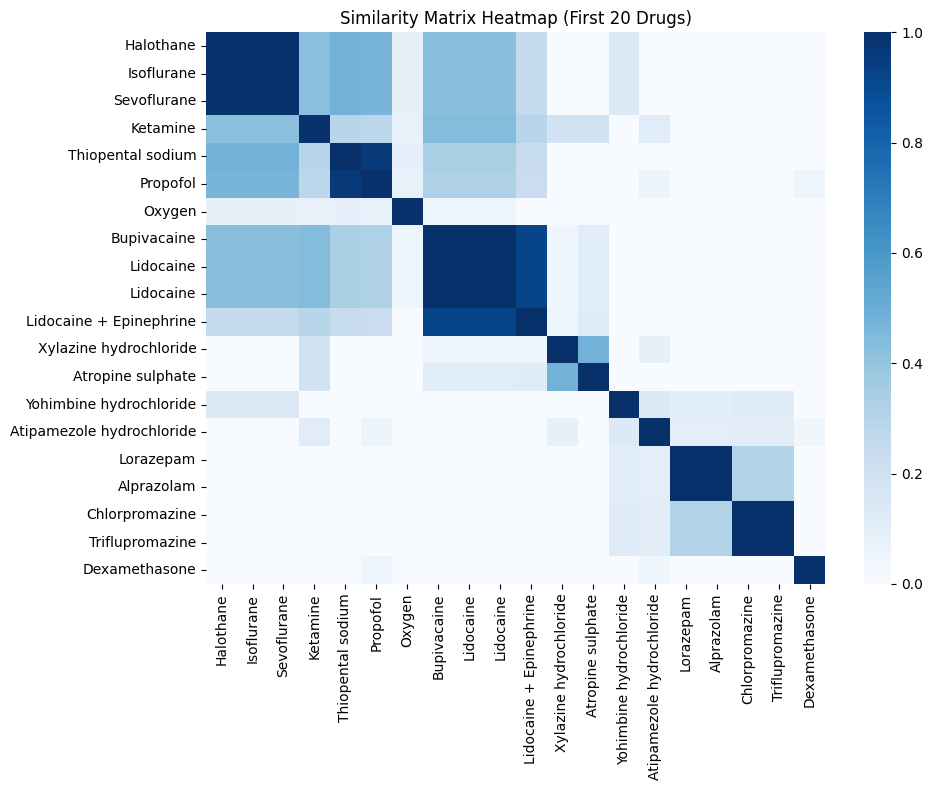

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. mathematical similarity between all vector configurations
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# 2. Render the structural similarity matrix heatmap for the first 20 drugs
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim[:20, :20], annot=False, cmap='Blues',
            xticklabels=df['generic_name'].head(20),
            yticklabels=df['generic_name'].head(20))
plt.title('Similarity Matrix Heatmap (First 20 Drugs)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
def recommend_substitutes(generic_name, top_n=3):
    matches = df[df['generic_name'].str.lower() == generic_name.lower()]
    if matches.empty:
        print(f" Drug '{generic_name}' not found in database.")
        return []

    idx = matches.index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [score for score in sim_scores if score[0] != idx][:top_n]

    recommendations = df.iloc[[i[0] for i in sim_scores]][['generic_name', 'category', 'indications']]
    return recommendations.to_dict(orient='records') # Output clean JSON-like dictionaries

def recommend_by_symptom(query, top_n=3):
    query_vector = tfidf.transform([query])
    symptom_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()
    top_indices = symptom_scores.argsort()[-top_n:][::-1]

    recommendations = df.iloc[top_indices][['generic_name', 'category', 'indications']]
    return recommendations.to_dict(orient='records')

# Execution Tests
print("--- TEST 1: Alternatives for Halothane ---")
print(recommend_substitutes('Halothane'))

print("\n--- TEST 2: Symptom Search for 'parasite infection' ---")
print(recommend_by_symptom('parasite infection'))

--- TEST 1: Alternatives for Halothane ---
[{'generic_name': 'Isoflurane', 'category': 'Inhalant anaesthetics', 'indications': 'General anaesthesia for clinical and surgical procedures'}, {'generic_name': 'Sevoflurane', 'category': 'Inhalant anaesthetics', 'indications': 'General anaesthesia for clinical and surgical procedures'}, {'generic_name': 'Thiopental sodium', 'category': 'Barbiturate', 'indications': 'General anaesthesia in major and minor surgical procedures'}]

--- TEST 2: Symptom Search for 'parasite infection' ---
[{'generic_name': 'Benzoic acid and Salicylic acid', 'category': 'Antifungal', 'indications': 'Fungal infection'}, {'generic_name': 'Miconazole', 'category': 'Antifungal', 'indications': 'Fungal infection'}, {'generic_name': 'Nystatin', 'category': 'Antifungal', 'indications': 'Fungal infection'}]


In [ ]:
def run_engine_self_check():
    print("====== STARTING ENGINE DIAGNOSTIC SELF-CHECK ======\n")

    # Check 1: Verify data is loaded
    if 'df' in globals() and df is not None:
        print(f" Data Check Passed: Found active database with {len(df)} entries.")
    else:
        print(" Data Check Failed: 'df' is not defined. Run Cell 1 first.")
        return

    # Check 2: Test empty/garbage input for symptom search
    try:
        garbage_result = recommend_by_symptom("xyz123abc!!!")
        print(" Edge Case Check 1 Passed: System safely handles nonsense text inputs without crashing.")
    except Exception as e:
        print(f" Edge Case Check 1 Failed: System crashed on nonsense text. Error: {e}")

    # Check 3: Test out-of-bounds drug name
    try:
        missing_drug_result = recommend_substitutes("ImaginaryDrugPhen")
        if missing_drug_result == []:
            print("Edge Case Check 2 Passed: System gracefully catches unrecognized drug names.")
        else:
            print("Edge Case Check 2 Warning: System returned unexpected results for a missing drug.")
    except Exception as e:
        print(f"Edge Case Check 2 Failed: System crashed on missing drug name. Error: {e}")

    print("\n====== DIAGNOSTIC COMPLETE: ENGINE IS STABLE ======")

# Run the self-check
run_engine_self_check()

====== STARTING ENGINE DIAGNOSTIC SELF-CHECK ======

 Data Check Passed: Found active database with 224 entries.
 Edge Case Check 1 Passed: System safely handles nonsense text inputs without crashing.
 Drug 'ImaginaryDrugPhen' not found in database.
Edge Case Check 2 Passed: System gracefully catches unrecognized drug names.

====== DIAGNOSTIC COMPLETE: ENGINE IS STABLE ======


In [ ]:

worm_recommendations = recommend_by_symptom("worm infestation", top_n=3)

# Print the cleanly formatted results
import json
print(json.dumps(worm_recommendations, indent=4))

[
    {
        "generic_name": "Praziquantel",
        "category": "Anthelmintics",
        "indications": "Cestode infestation, nematodiasis and mixed infestation"
    },
    {
        "generic_name": "Praziquantel combination with Fenbendazole and Pyrantel pamoate",
        "category": "Anthelmintics",
        "indications": "Cestode infestation, nematodiasis and mixed infestation"
    },
    {
        "generic_name": "Fenbendazole",
        "category": "Anthelmintics",
        "indications": "Nematodal infestation"
    }
]


In [ ]:
if df.to_csv(r"D:\Projects\PetCare\data\cleaned_veterinary_medicine.csv", index=False):
  print("Success")


In [ ]:
df.to_csv("cleaned_veterinary_medicine.csv", index=False)

In [ ]:
from google.colab import files

files.download("cleaned_veterinary_medicine.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.columns

Index(['generic_name', 'dosage_form', 'strength', 'category', 'indications',
       'list_tier', 'source', 'metadata'],
      dtype='object')

In [ ]:
import pandas as pd

df = pd.read_csv("cleaned_veterinary_medicine.csv")

In [ ]:
text_columns = [
    "generic_name",
    "category",
    "dosage_form",
    "strength",
    "indications"
]

df[text_columns] = df[text_columns].fillna("")


In [ ]:
df.isna().sum()

,0
generic_name,0
dosage_form,0
strength,0
category,0
indications,0
list_tier,12
source,0
metadata,0


In [ ]:
# Converting to lower case
for col in text_columns:
    df[col] = df[col].str.lower().str.strip()

In [ ]:
#- extra space
for col in text_columns:
    df[col] = df[col].str.replace(r"\s+", " ", regex=True)

In [ ]:
#combined column
df["combined_features"] = (
    df["generic_name"] + " " +
    df["category"] + " " +
    df["dosage_form"] + " " +
    df["strength"] + " " +
    df["indications"]
)

In [ ]:
df["combined_features"] = (
    df["generic_name"] + " " +
    df["category"] + " " +
    df["category"] + " " +
    df["dosage_form"] + " " +
    df["strength"] + " " +
    df["indications"] + " " +
    df["indications"]
)

In [ ]:
df[["generic_name", "combined_features"]].head(10)

,generic_name,combined_features
0,halothane,halothane inhalant anaesthetics inhalant anaes...
1,isoflurane,isoflurane inhalant anaesthetics inhalant anae...
2,sevoflurane,sevoflurane inhalant anaesthetics inhalant ana...
3,ketamine,ketamine dissociative anaesthetic dissociative...
4,thiopental sodium,thiopental sodium barbiturate barbiturate inje...
5,propofol,propofol non barbiturate non barbiturate injec...
6,oxygen,oxygen oxygen oxygen inhalation (medical gas) ...
7,bupivacaine,bupivacaine local anaesthetic local anaestheti...
8,lidocaine,lidocaine local anaesthetic local anaesthetic ...
9,lidocaine,lidocaine local anaesthetic local anaesthetic ...


In [ ]:
df["combined_features"].str.len().describe()

,combined_features
count,224.000000
mean,163.816964
std,64.983113
min,44.000000
25%,116.750000
50%,157.000000
75%,195.250000
max,416.000000


In [ ]:
(df["combined_features"] == "").sum()

np.int64(0)

In [ ]:
df.to_csv("cleaned_veterinary_medicine.csv", index=False)

In [ ]:
print(df["combined_features"].head())

print(df["combined_features"].isnull().sum())

print(df["combined_features"].iloc[0])

0    halothane inhalant anaesthetics inhalant anaes...
1    isoflurane inhalant anaesthetics inhalant anae...
2    sevoflurane inhalant anaesthetics inhalant ana...
3    ketamine dissociative anaesthetic dissociative...
4    thiopental sodium barbiturate barbiturate inje...
Name: combined_features, dtype: object
0
halothane inhalant anaesthetics inhalant anaesthetics inhalation 4-6% and 1-1.5%, 30ml, 50ml, 200ml, 250ml general anaesthesia for clinical and surgical procedures general anaesthesia for clinical and surgical procedures


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:

#vectorizer
tfidf = TfidfVectorizer(
    stop_words="english"
)

In [ ]:
tfidf_matrix = tfidf.fit_transform(df["combined_features"])

In [ ]:
#shape
print(tfidf_matrix.shape)

(224, 781)


In [ ]:

print(tfidf.get_feature_names_out()[:30])

['000' '05' '10' '100' '1000iu' '1000ml' '100gm' '100mg' '100ml' '10mg'
 '10ml' '11' '110gm' '12' '120mg' '125' '125mg' '12lac' '140mg' '144mg'
 '15' '150' '1500mg' '150mg' '15gm' '15mg' '15ml' '18' '1800' '1gm']


In [ ]:
print(tfidf_matrix[2])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11 stored elements and shape (1, 781)>
  Coords	Values
  (0, 455)	0.3969085646974159
  (0, 149)	0.3793000155903195
  (0, 456)	0.18965000779515975
  (0, 392)	0.3649127833930152
  (0, 147)	0.31021563397753044
  (0, 260)	0.3246028661748347
  (0, 697)	0.31708181539112884
  (0, 621)	0.3246028661748347
  (0, 670)	0.22580285705645034
  (0, 69)	0.22580285705645034
  (0, 763)	0.14136514888513685


In [ ]:
vector = tfidf_matrix[2].toarray()

print(vector)

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.22580286 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.   

In [ ]:
#which word matters most
feature_names = tfidf.get_feature_names_out()

vector = tfidf_matrix[2].toarray().flatten()

top_indices = vector.argsort()[-10:][::-1]

for idx in top_indices:
    print(feature_names[idx], vector[idx])

inhalant 0.3969085646974159
anaesthetics 0.3793000155903195
general 0.3649127833930152
procedures 0.3246028661748347
clinical 0.3246028661748347
surgical 0.31708181539112884
anaesthesia 0.31021563397753044
sevoflurane 0.22580285705645034
3ml 0.22580285705645034
inhalation 0.18965000779515975


In [ ]:
print("Number of medicines:", tfidf_matrix.shape[0])
print("Vocabulary size:", tfidf_matrix.shape[1])

Number of medicines: 224
Vocabulary size: 781


In [ ]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[500:530])

['loperamide' 'lorazepam' 'loss' 'lotion' 'luteal' 'lymphoproliferative'
 'lymphosarcoma' 'macrolide' 'maduramycin' 'magnesia' 'magnesium' 'major'
 'maleate' 'mannitol' 'mast' 'mastitis' 'mebendazole' 'medical'
 'meglumine' 'meloxicam' 'metabolism' 'metal' 'methylene' 'metoclopramide'
 'metoprolol' 'metronidazole' 'mg' 'miconazole' 'microsporum' 'milk']


In [ ]:
feature_names = tfidf.get_feature_names_out()

vector = tfidf_matrix[9].toarray().flatten()

top_indices = vector.argsort()[-15:][::-1]

for idx in top_indices:
    print(feature_names[idx], ":", round(vector[idx], 3))

anaesthesia : 0.693
facilitate : 0.222
nerve : 0.212
epidural : 0.212
regional : 0.212
surface : 0.212
infiltration : 0.212
block : 0.212
local : 0.212
anaesthetic : 0.191
procedures : 0.181
clinical : 0.181
surgical : 0.177
topical : 0.111
lidocaine : 0.106


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [ ]:
print(cosine_sim)

[[1.         0.7936752  0.84619118 ... 0.         0.         0.        ]
 [0.7936752  1.         0.82354933 ... 0.         0.         0.        ]
 [0.84619118 0.82354933 1.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 1.         0.59258965 0.57187897]
 [0.         0.         0.         ... 0.59258965 1.         0.51538448]
 [0.         0.         0.         ... 0.57187897 0.51538448 1.        ]]


In [ ]:
print(cosine_sim.shape)

(224, 224)


In [ ]:
print(cosine_sim[2])

[0.84619118 0.82354933 1.         0.35990469 0.41675968 0.39989073
 0.0894496  0.38450783 0.38739603 0.38870209 0.23217801 0.
 0.         0.11844151 0.         0.         0.         0.
 0.02008777 0.         0.01718823 0.         0.         0.01769769
 0.         0.         0.         0.         0.         0.02041438
 0.018727   0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.01636179
 0.01912134 0.01907667 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.08551119
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.  

In [ ]:
similarities = list(enumerate(cosine_sim[1]))

similarities = sorted(similarities, key=lambda x: x[1], reverse=True)

similarities[:10]

[(1, np.float64(1.0000000000000004)),
 (2, np.float64(0.8235493344389688)),
 (0, np.float64(0.7936751963095166)),
 (5, np.float64(0.39235379264850356)),
 (4, np.float64(0.3908948999595315)),
 (3, np.float64(0.37079593579087944)),
 (9, np.float64(0.3645786097838071)),
 (8, np.float64(0.36335360971560166)),
 (7, np.float64(0.3606446522039447)),
 (10, np.float64(0.207021063166462))]

In [ ]:
similarities = list(enumerate(cosine_sim[2]))

similarities = sorted(similarities, key=lambda x: x[1], reverse=True)

similarities[:10]

[(2, np.float64(1.0)),
 (0, np.float64(0.8461911809004041)),
 (1, np.float64(0.8235493344389688)),
 (4, np.float64(0.4167596751703292)),
 (5, np.float64(0.3998907328454174)),
 (9, np.float64(0.3887020859143463)),
 (8, np.float64(0.3873960299116669)),
 (7, np.float64(0.3845078258119836)),
 (3, np.float64(0.35990468521046526)),
 (10, np.float64(0.23217801362228738))]

In [ ]:
for idx, score in similarities[0:11]:
    print(df.iloc[idx]["generic_name"], ":", round(score, 3))

sevoflurane : 1.0
halothane : 0.846
isoflurane : 0.824
thiopental sodium : 0.417
propofol : 0.4
lidocaine : 0.389
lidocaine : 0.387
bupivacaine : 0.385
ketamine : 0.36
lidocaine + epinephrine : 0.232
yohimbine hydrochloride : 0.118


In [ ]:
similarities = list(enumerate(cosine_sim[0]))
similarities = sorted(similarities, key=lambda x: x[1], reverse=True)

similarities[:10]

[(0, np.float64(1.0000000000000002)),
 (2, np.float64(0.8461911809004041)),
 (1, np.float64(0.7936751963095166)),
 (4, np.float64(0.4016417756320996)),
 (5, np.float64(0.3853847518554014)),
 (9, np.float64(0.3746019715432721)),
 (8, np.float64(0.37334329254133475)),
 (7, np.float64(0.37055985764564675)),
 (3, np.float64(0.34684919256443075)),
 (10, np.float64(0.21271269441486954))]

In [ ]:
for idx, score in similarities[1:6]:
    print(df.iloc[idx]["generic_name"], ":", round(score, 3))

sevoflurane : 0.846
isoflurane : 0.794
thiopental sodium : 0.402
propofol : 0.385
lidocaine : 0.375


### Reccomendation Function
  
  1.  Recommend medicines similar to the given medicine.

   2. Parameters:
        medicine_name (str): Name of the medicine
        top_n (int): Number of recommendations

   3. Returns:
   '''
        pandas.DataFrame
  '''


In [ ]:
# Create a mapping from medicine name to DataFrame index
medicine_indices = pd.Series(df.index, index=df["generic_name"]).drop_duplicates()

medicine_indices.head()

,0
generic_name,
halothane,0
isoflurane,1
sevoflurane,2
ketamine,3
thiopental sodium,4


In [ ]:
def recommend_medicine(medicine_name, top_n=5):

    # Convert input to lowercase
    medicine_name = medicine_name.lower().strip()

    # Check if medicine exists
    if medicine_name not in medicine_indices:
        print(f"Medicine '{medicine_name}' not found in the dataset.")
        return None

    # Get index of selected medicine
    idx = medicine_indices[medicine_name]

    # Similarity scores
    similarity_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove itself
    similarity_scores = similarity_scores[1:top_n+1]

    # Store recommendations
    recommendations = []

    for index, score in similarity_scores:
        recommendations.append({
            "Medicine": df.iloc[index]["generic_name"],
            "Category": df.iloc[index]["category"],
            "Dosage Form": df.iloc[index]["dosage_form"],
            "Similarity Score": round(score, 3)
        })

    return pd.DataFrame(recommendations)

In [ ]:
recommend_medicine("ketamine")

,Medicine,Category,Dosage Form,Similarity Score
0,bupivacaine,local anaesthetic,injection,0.428
1,lidocaine,local anaesthetic,injection,0.404
2,lidocaine,local anaesthetic,topical,0.401
3,isoflurane,inhalant anaesthetics,inhalation,0.371
4,sevoflurane,inhalant anaesthetics,inhalation,0.360


In [ ]:
recommend_medicine("paracetamol")

,Medicine,Category,Dosage Form,Similarity Score
0,tolfenamic acid,steroidal and non-steroidal antiinflammatory d...,injection,0.845
1,meloxicam,steroidal and non-steroidal antiinflammatory d...,"tablet, injection, suspension",0.768
2,pethidine,steroidal and non-steroidal antiinflammatory d...,injection,0.609
3,fentanyl,steroidal and non-steroidal antiinflammatory d...,injection,0.586
4,morphine,steroidal and non-steroidal antiinflammatory d...,"tablet, injection,liquid",0.560


In [ ]:
df[df["generic_name"].str.contains("paracetamol", case=False, na=False)]

,generic_name,dosage_form,strength,category,indications,list_tier,source,metadata,combined_features
24,paracetamol,"injectable, tablet, bolus","injection(1mg/ml): 10ml,30ml, tablet: 150mg, 1.5g",steroidal and non-steroidal antiinflammatory d...,pyrexia of unknown origin,Essential,National Essential Veterinary Medicine List 20...,Steroidal and Non-steroidal antiinflammatory d...,paracetamol steroidal and non-steroidal antiin...


### Initial search by symptoms or other querries like "**worms**","**rabies**"


In [ ]:
# Does the dataset contain the word "worm"?
df[df["combined_features"].str.contains("worm", case=False, na=False)]

,generic_name,dosage_form,strength,category,indications,list_tier,source,metadata,combined_features


In [ ]:
df[df["combined_features"].str.contains("helminth", case=False, na=False)]

,generic_name,dosage_form,strength,category,indications,list_tier,source,metadata,combined_features


In [ ]:
df[df["combined_features"].str.contains("rabies", case=False, na=False)]

,generic_name,dosage_form,strength,category,indications,list_tier,source,metadata,combined_features


In [ ]:
df[df["combined_features"].str.contains("helminth", case=False, na=False)]

,generic_name,dosage_form,strength,category,indications,list_tier,source,metadata,combined_features


In [ ]:
feature_names = tfidf.get_feature_names_out()

print("worm" in feature_names)
print("helminth" in feature_names)
print("parasite" in feature_names)
print("rabies" in feature_names)

False
False
False
False


In [ ]:
keywords = [
    "parasite",
    "anthelmintic",
    "nematode",
    "cestode",
    "ectoparasite",
    "endoparasite",
    "tick",
    "flea",
    "rabies",
    "vaccine",
    "pain",
    "infection",
    "mastitis",
    "diarr",
    "pyrexia"
]

for word in keywords:
    count = df["combined_features"].str.contains(word, case=False, na=False).sum()
    print(f"{word}: {count}")

parasite: 4
anthelmintic: 18
nematode: 0
cestode: 4
ectoparasite: 4
endoparasite: 0
tick: 0
flea: 0
rabies: 0
vaccine: 0
pain: 7
infection: 28
mastitis: 2
diarr: 2
pyrexia: 4


In [ ]:
df[df["generic_name"].str.contains("alb", case=False, na=False)]

,generic_name,dosage_form,strength,category,indications,list_tier,source,metadata,combined_features
34,salbutamol,"tablet, syrup","2mg,4mg, 2mg/5ml",expectorants and bronchodialators,brochospasm,Essential,National Essential Veterinary Medicine List 20...,Expectorants and Bronchodialators Brochospasm,salbutamol expectorants and bronchodialators e...
135,albendazole,"tablet, bolus,powder","150mg, 200mg, 600mg,1500mg,3000mg,2.5%w/v, 5%w/w",anthelmintics,nematodal and cestodal infestation,Essential,National Essential Veterinary Medicine List 20...,Anthelmintics Nematodal and cestodal infestation,albendazole anthelmintics anthelmintics tablet...
146,praziquantel and albendazole,tablet,25mg+300mg,anthelmintics,sctariasis,Essential,National Essential Veterinary Medicine List 20...,Anthelmintics Sctariasis,praziquantel and albendazole anthelmintics ant...


In [ ]:
df[["generic_name", "category", "indications"]].head(10)

,generic_name,category,indications
0,halothane,inhalant anaesthetics,general anaesthesia for clinical and surgical ...
1,isoflurane,inhalant anaesthetics,general anaesthesia for clinical and surgical ...
2,sevoflurane,inhalant anaesthetics,general anaesthesia for clinical and surgical ...
3,ketamine,dissociative anaesthetic,"anaesthesia, immobilization for clinical exami..."
4,thiopental sodium,barbiturate,general anaesthesia in major and minor surgica...
5,propofol,non barbiturate,general anaesthesia in major and minor surgica...
6,oxygen,oxygen,medical and surgical conditions requiring oxygen
7,bupivacaine,local anaesthetic,"infiltration anaesthesia, surface anaesthesia,..."
8,lidocaine,local anaesthetic,"infiltration anaesthesia, surface anaesthesia,..."
9,lidocaine,local anaesthetic,"infiltration anaesthesia, surface anaesthesia,..."


In [ ]:
keyword_map = {

    "worm": """
        worm worms parasite parasitic
        ivermectin albendazole fenbendazole levamisole
    """,

    "deworm": """
        deworm worm parasite
        ivermectin albendazole fenbendazole levamisole
    """,

    "parasite": """
        parasite parasitic
        ivermectin albendazole fenbendazole levamisole
    """,

    "pain": """
        pain analgesic anti inflammatory
        meloxicam ketoprofen paracetamol
    """,

    "diarrhea": """
        diarrhea diarrhoea gastrointestinal
    """,

    "rabies": """
        rabies vaccine vaccination
    """
}

In [ ]:
def expand_query(query):

    query = query.lower().strip()

    expanded = []

    for word in query.split():

        expanded.append(keyword_map.get(word, word))

    return " ".join(expanded)
    #

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def search_medicine(query, top_n=5):

    query = correct_query(query)
    query = expand_query(query)

    # Convert query to TF-IDF vector
    query_vector = tfidf.transform([query])

    # Calculate similarity
    scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Get top matches
    top_indices = scores.argsort()[::-1]

    recommendations = []

    for idx in top_indices:

        # Skip completely unrelated results
        if scores[idx] <= 0:
            continue

        recommendations.append({
            "Medicine": df.iloc[idx]["generic_name"].title(),
            "Category": df.iloc[idx]["category"].title(),
            "Dosage Form": df.iloc[idx]["dosage_form"].title(),
            "Strength": df.iloc[idx]["strength"],
            "Indications": df.iloc[idx]["indications"],
            "Similarity (%)": f"{scores[idx]*100:.2f}%"
        })

        if len(recommendations) == top_n:
            break

    return pd.DataFrame(recommendations)

In [ ]:
VET_KNOWLEDGE = {

    # Parasites
    "worm": [
        "worm",
        "worms",
        "parasite",
        "parasitic",
        "anthelmintic",
        "albendazole",
        "fenbendazole",
        "levamisole",
        "ivermectin"
    ],

    "deworm": [
        "worm",
        "parasite",
        "albendazole",
        "fenbendazole",
        "levamisole",
        "ivermectin"
    ],

    "parasite": [
        "parasite",
        "ivermectin",
        "albendazole",
        "fenbendazole",
        "levamisole"
    ],

    # Viral diseases
    "rabies": [
        "rabies",
        "vaccine",
        "vaccination"
    ],

    # Pain
    "pain": [
        "pain",
        "analgesic",
        "meloxicam",
        "ketoprofen",
        "paracetamol",
        "tolfenamic"
    ],

    # Fever
    "fever": [
        "fever",
        "pyrexia",
        "anti-inflammatory"
    ],

    # Skin
    "skin": [
        "skin",
        "dermatitis",
        "wound",
        "topical"
    ],

    # Tick
    "tick": [
        "tick",
        "ectoparasite",
        "acaricide",
        "ivermectin"
    ],

    # Infection
    "infection": [
        "infection",
        "antibiotic",
        "antimicrobial",
        "penicillin",
        "amoxicillin",
        "oxytetracycline"
    ],

    # Diarrhoea
    "diarrhea": [
        "diarrhea",
        "diarrhoea",
        "gastrointestinal"
    ]
}

In [ ]:
def expand_query(query):

    query = query.lower().strip()

    expanded = []

    for word in query.split():

        if word in VET_KNOWLEDGE:

            expanded.extend(VET_KNOWLEDGE[word])

        else:

            expanded.append(word)

    return " ".join(expanded)

In [ ]:
expand_query("worm")

'worm worms parasite parasitic anthelmintic albendazole fenbendazole levamisole ivermectin'

In [ ]:
from difflib import get_close_matches

In [ ]:
medicine_list = df["generic_name"].str.lower().unique().tolist()

print(f"Total medicines: {len(medicine_list)}")

Total medicines: 212


In [ ]:
def correct_query(query):

    # Convert input to lowercase for consistent matching
    lower_query = query.lower().strip()

    match = get_close_matches(
        lower_query,
        medicine_list,
        n=1,
        cutoff=0.7
    )

    if match:
        return match[0] # Return the best matched medicine name

    return lower_query # If no close match, return the original lowercased query

In [ ]:
print(correct_query("ketan"))

ketamine


### Smart Search
   
    A. Smart veterinary medicine search using:
    1. Fuzzy matching
    2. Query expansion
    3. TF-IDF
    4. Cosine similarity
    

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def smart_search(query, top_n=5):

    # Step 1: Correct spelling
    query = correct_query(query)

    # Step 2: Expand veterinary keywords
    query = expand_query(query)

    # Step 3: Convert query to TF-IDF vector
    query_vector = tfidf.transform([query])

    # Step 4: Compute similarity
    scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Step 5: Sort by similarity
    top_indices = scores.argsort()[::-1]

    recommendations = []

    for idx in top_indices:

        # Ignore unrelated medicines
        if scores[idx] <= 0:
            continue

        recommendations.append({
            "Medicine": df.iloc[idx]["generic_name"].title(),
            "Category": df.iloc[idx]["category"].title(),
            "Dosage Form": df.iloc[idx]["dosage_form"].title(),
            "Strength": df.iloc[idx]["strength"],
            "Indications": df.iloc[idx]["indications"],
            "Similarity (%)": round(scores[idx] * 100, 2)
        })

        if len(recommendations) == top_n:
            break

    if len(recommendations) == 0:
        return pd.DataFrame(
            [{
                "Message": "No relevant medicines found."
            }]
        )

    return pd.DataFrame(recommendations)

In [ ]:
smart_search("worm")

,Medicine,Category,Dosage Form,Strength,Indications,Similarity (%)
0,Ivermectin + Clorsulon,Anthelmintics,Injection (1%Ivermectin+10% Clorsulon),"10ml, 50ml,100ml",cestode infestation,23.79
1,Praziquantel And Albendazole,Anthelmintics,Tablet,25mg+300mg,sctariasis,16.14
2,Fenbendazole,Anthelmintics,"Tablet, Bolus,Suspension, Powder","150mg, 1500mg, 3000mg, 10% w/v, 25% w/w",nematodal infestation,14.26
3,Albendazole,Anthelmintics,"Tablet, Bolus,Powder","150mg, 200mg, 600mg,1500mg,3000mg,2.5%w/v, 5%w/w",nematodal and cestodal infestation,12.14
4,Ivermectin,Anthelmintics,Injection (1%),"1ml, 10ml, 50ml,100ml",endectocide and flukicidal action,11.60


In [ ]:
smart_search("ketamine")

,Medicine,Category,Dosage Form,Strength,Indications,Similarity (%)
0,Atipamezole,Antidotes,Injection,5mg/ml in 10 ml,reverse the effect of ketamine,47.76
1,Ketamine,Dissociative Anaesthetic,Injection,"10mg/ml, and 50mg/ml: 2ml, 10ml, 20ml","anaesthesia, immobilization for clinical exami...",18.53


In [ ]:
smart_search("worms")

,Message
0,No relevant medicines found.


In [ ]:
smart_search("diarrhea")

,Medicine,Category,Dosage Form,Strength,Indications,Similarity (%)
0,Loperamide,Antidiarrhoeals,Tablet,2mg,acute and chronic non-specific diarrhoea,45.84


In [ ]:
smart_search("infection")

,Medicine,Category,Dosage Form,Strength,Indications,Similarity (%)
0,Amoxicillin,Antibacterial - Penicillin,"Bolus, Injection,Powder","1.5gm, 5%w/w",gram +ve and gram negative bacterial infection,38.92
1,Fortified Procaine Penicillin,Antibacterial - Penicillin,Injection,"20lac,40lac",gram +ve and gram negative bacterial infection,32.02
2,Amoxicillin And Clavulanic Acid,Antibacterial - Penicillin,"Tablet,Syrup,Injection","250mg, 500mg, 228.75mg/5ml, 2gm, 3gm,4gm",mixed bacterial infections,30.52
3,Benzathine Penicillin,Antibacterial - Penicillin,Injection,"6lac ,12lac,24lac,48 lac iu",gram +ve and gram negative bacterial infection,30.28
4,Ampicillin,Antibacterial - Penicillin,Injection,"250mg,500mg, 2gm, 2.5gm",gram +ve and gram negative bacterial infection,26.63


In [ ]:
smart_search("rabies")

,Message
0,No relevant medicines found.


In [ ]:
sorted(df["category"].dropna().unique())

['antacids, antiulcer and ppi',
 'anthelmintics',
 'antiarrhythmic/antihypertensive/vasodilator drugs',
 'antibacterial - aminoglycoside',
 'antibacterial - amphenicols',
 'antibacterial - cephalosporin',
 'antibacterial - fluoroquinolone',
 'antibacterial - lincosamide',
 'antibacterial - macrolide',
 'antibacterial - nitrofuran',
 'antibacterial - penicillin',
 'antibacterial - pleuromutilins',
 'antibacterial - sulphonamide group',
 'antibacterial - tetracyclines',
 'anticonvulsant/antiepileptics',
 'antidiarrhoeals',
 'antidotes',
 'antidotes of sedatives',
 'antiemetics',
 'antifungal',
 'antihistamines for anaphylaxis',
 'antineoplastic',
 'antiprotozoal drugs/ionophores',
 'antiseptics',
 'antispasmodic',
 'antitubercular drugs',
 'antiviral drugs',
 'antizymotics',
 'barbiturate',
 'cardiotonic glycoside',
 'dermatological: anti-inflammatory/antipruritic',
 'dissociative anaesthetic',
 'diuretics',
 'ear, nose and throat preparations',
 'expectorants and bronchodialators',
 'ha

In [ ]:
CATEGORY_KEYWORDS = {

    # Parasites
    "anthelmintics": """
        worm worms deworm deworming
        parasite parasites parasitic
        helminth helminths
        roundworm tapeworm hookworm
        nematode nematodes cestode cestodes
    """,

    "insecticidal": """
        insect insects
        tick ticks
        flea fleas
        mite mites
        lice louse
        ectoparasite ectoparasites
        external parasite
    """,

    "antiprotozoal drugs/ionophores": """
        protozoa protozoal
        coccidia coccidiosis
        giardia
        trichomonas
        protozoal infection
    """,

    # Bacterial infections
    "antibacterial - aminoglycoside": """
        bacterial bacteria
        bacterial infection infection
        antimicrobial antibiotic
    """,

    "antibacterial - amphenicols": """
        bacterial bacteria
        bacterial infection infection
        antimicrobial antibiotic
    """,

    "antibacterial - cephalosporin": """
        bacterial bacteria
        bacterial infection infection
        antimicrobial antibiotic
    """,

    "antibacterial - fluoroquinolone": """
        bacterial bacteria
        bacterial infection infection
        antimicrobial antibiotic
    """,

    "antibacterial - lincosamide": """
        bacterial bacteria
        bacterial infection infection
        antimicrobial antibiotic
    """,

    "antibacterial - macrolide": """
        bacterial bacteria
        bacterial infection infection
        antimicrobial antibiotic
    """,

    "antibacterial - nitrofuran": """
        bacterial bacteria
        bacterial infection infection
        antimicrobial antibiotic
    """,

    "antibacterial - penicillin": """
        bacterial bacteria
        bacterial infection infection
        antimicrobial antibiotic
    """,

    "antibacterial - pleuromutilins": """
        bacterial bacteria
        bacterial infection infection
        antimicrobial antibiotic
    """,

    "antibacterial - sulphonamide group": """
        bacterial bacteria
        bacterial infection infection
        antimicrobial antibiotic
    """,

    "antibacterial - tetracyclines": """
        bacterial bacteria
        bacterial infection infection
        antimicrobial antibiotic
    """,

    # Antifungal
    "antifungal": """
        fungal fungus
        fungal infection
        yeast
        ringworm
        mycosis
    """,

    # Inflammation and pain
    "steroidal and non-steroidal antiinflammatory drugs (nsaids)": """
        pain painful
        inflammation inflammatory
        swelling
        fever pyrexia
        analgesic analgesia
        anti-inflammatory
    """,

    "dermatological: anti-inflammatory/antipruritic": """
        skin skin disease
        dermatitis
        itching itch pruritus
        inflammation
        allergy allergic
        rash
    """,

    # Gastrointestinal
    "antidiarrhoeals": """
        diarrhea diarrhoea
        loose stool
        gastrointestinal
        digestive
    """,

    "antacids, antiulcer and ppi": """
        stomach gastric
        ulcer
        acidity acid
        gastrointestinal
        gastritis
    """,

    "antiemetics": """
        vomiting vomit
        nausea
        gastrointestinal
    """,

    "antispasmodic": """
        abdominal pain
        stomach pain
        intestinal spasm
        gastrointestinal
    """,

    "laxatives and purgatives": """
        constipation
        bowel
        intestinal
        laxative
    """,

    # Respiratory
    "expectorants and bronchodialators": """
        cough
        respiratory
        breathing
        bronchitis
        bronchodilator
        airway
    """,

    # Allergy
    "antihistamines for anaphylaxis": """
        allergy allergic
        itching itch
        anaphylaxis
        hypersensitivity
    """,

    # Anaesthesia and sedation
    "inhalant anaesthetics": """
        anaesthesia anesthesia
        anaesthetic anesthetic
        surgery surgical
        sedation
    """,

    "dissociative anaesthetic": """
        anaesthesia anesthesia
        anaesthetic anesthetic
        surgery surgical
        sedation
    """,

    "barbiturate": """
        anaesthesia anesthesia
        anaesthetic anesthetic
        sedation
        seizure
        epilepsy
    """,

    "non barbiturate": """
        anaesthesia anesthesia
        anaesthetic anesthetic
        sedation
    """,

    "local anaesthetic": """
        local anesthesia
        local anaesthetic
        pain
        surgery
    """,

    "sedative/pre-anaesthetic": """
        sedation
        sedative
        pre-anesthetic
        pre-anaesthetic
        anxiety
    """,

    "sedatives and tranquilizers": """
        sedation
        sedative
        tranquilizer
        anxiety
        nervousness
    """,

    # Neurological
    "anticonvulsant/antiepileptics": """
        seizure seizures
        epilepsy epileptic
        convulsion convulsions
    """,

    # Cardiovascular
    "antiarrhythmic/antihypertensive/vasodilator drugs": """
        heart
        cardiac
        hypertension
        high blood pressure
        arrhythmia
        blood pressure
    """,

    "cardiotonic glycoside": """
        heart
        cardiac
        heart failure
        cardiac failure
    """,

    "diuretics": """
        fluid retention
        edema oedema
        heart failure
        kidney
        diuresis
    """,

    # Antiviral
    "antiviral drugs": """
        virus viral
        viral infection
        antiviral
    """,

    # Antiseptic
    "antiseptics": """
        antiseptic
        wound
        wound care
        infection
        skin
    """,

    # Antitubercular
    "antitubercular drugs": """
        tuberculosis
        tb
        mycobacterium
        bacterial infection
    """,

    # Vitamins and minerals
    "vitamins and minerals": """
        vitamin
        mineral
        deficiency
        nutritional deficiency
        supplement
    """,

    # Hematinics
    "hematinics": """
        anemia anaemia
        iron deficiency
        blood
        red blood cells
    """, # <--- Added comma here
    # Antidotes
    "antidotes": """
        poisoning poison toxicity toxic
        overdose antidote
    """,

    "antidotes of sedatives": """
        sedative overdose
        sedation reversal
        poisoning toxicity
        antidote
    """,

    # Cancer
    "antineoplastic": """
        cancer tumor tumour
        neoplasia neoplasm
        chemotherapy
        cancer treatment
    """,

    # Enzymes / digestive
    "antizymotics": """
        fermentation
        digestive
        gastrointestinal
        intestinal
    """,

    # ENT
    "ear, nose and throat preparations": """
        ear infection
        otitis
        ear nose throat
        nasal
        sinus
        throat
    """,

    # Bleeding
    "haemostatics": """
        bleeding hemorrhage haemorrhage
        blood clot clotting
        coagulation
    """,

    # Liver
    "hepatobiliary drugs": """
        liver hepatic
        hepatobiliary
        gallbladder
        bile
        liver disease
    """,

    # Hormones
    "hormones and endocrine preparations": """
        hormone hormonal
        endocrine
        diabetes
        insulin
        thyroid
        reproductive
    """,

    # Fluids
    "infusion fluids and electrolytes": """
        dehydration
        fluid therapy
        electrolyte
        intravenous
        IV fluids
        hydration
    """,

    # Miscellaneous
    "miscellaneous": """
        general treatment
        veterinary medicine
        supportive treatment
    """,

    # Muscle relaxation
    "muscle relaxants": """
        muscle
        muscle spasm
        muscle relaxation
        spasm
        skeletal muscle
    """,

    # Eye
    "ophthalmological": """
        eye eyes
        ocular
        ophthalmic
        conjunctivitis
        eye infection
    """,

    # Oxygen
    "oxygen": """
        oxygen
        respiratory
        breathing
        hypoxia
        oxygen therapy
    """,

    # Anticoagulants
    "systemic anticoagulants": """
        blood clot
        clotting
        thrombosis
        anticoagulant
        thrombus
    """
}

In [ ]:
dataset_categories = set(df["category"].dropna().str.lower().str.strip())

mapped_categories = set(CATEGORY_KEYWORDS.keys())

print("Categories in dataset:", len(dataset_categories))
print("Categories with mappings:", len(dataset_categories & mapped_categories))

print("\nCategories without mappings:")
print(sorted(dataset_categories - mapped_categories))

Categories in dataset: 54
Categories with mappings: 54

Categories without mappings:
[]


In [ ]:
def enrich_document(row):

    text = str(row["combined_features"])

    category = str(row["category"]).lower().strip()

    if category in CATEGORY_KEYWORDS:
        text += " " + CATEGORY_KEYWORDS[category]

    return text

In [ ]:
#creating new column
df["enriched_features"] = df.apply(enrich_document, axis=1)

In [ ]:
print(df[[
    "generic_name",
    "category",
    "combined_features",
    "enriched_features"
]].head(5))

        generic_name                  category  \
0          halothane     inhalant anaesthetics   
1         isoflurane     inhalant anaesthetics   
2        sevoflurane     inhalant anaesthetics   
3           ketamine  dissociative anaesthetic   
4  thiopental sodium               barbiturate   

                                   combined_features  \
0  halothane inhalant anaesthetics inhalant anaes...   
1  isoflurane inhalant anaesthetics inhalant anae...   
2  sevoflurane inhalant anaesthetics inhalant ana...   
3  ketamine dissociative anaesthetic dissociative...   
4  thiopental sodium barbiturate barbiturate inje...   

                                   enriched_features  
0  halothane inhalant anaesthetics inhalant anaes...  
1  isoflurane inhalant anaesthetics inhalant anae...  
2  sevoflurane inhalant anaesthetics inhalant ana...  
3  ketamine dissociative anaesthetic dissociative...  
4  thiopental sodium barbiturate barbiturate inje...  


In [ ]:
# Rebuilding TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    lowercase=True
)

tfidf_matrix = tfidf.fit_transform(
    df["enriched_features"]
)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
print("Vocabulary Size:", len(tfidf.get_feature_names_out()))

TF-IDF Matrix Shape: (224, 922)
Vocabulary Size: 922


In [ ]:
#Re building Cosine Similarities
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

print("Cosine Similarity Shape:", cosine_sim.shape)

Cosine Similarity Shape: (224, 224)


In [ ]:
features = tfidf.get_feature_names_out()

for word in [
    "worm",
    "parasite",
    "deworm",
    "helminth",
    "tick",
    "flea",
    "pain",
    "fever",
    "infection",
    "rabies"
]:
    print(word, "->", word in features)

worm -> True
parasite -> True
deworm -> True
helminth -> True
tick -> True
flea -> True
pain -> True
fever -> True
infection -> True
rabies -> False


In [ ]:
print(
    df[
        df["category"].str.lower().str.strip() == "anthelmintics"
    ][[
        "generic_name",
        "category",
        "enriched_features"
    ]].to_string(index=False)
)

                                                   generic_name      category                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              enriched_features
                                                    albendazole anthelmintics                                                                                                                                                            albendazole anthelmintics anthelmintics tablet, bolus,powder 150mg, 200mg, 600mg,1500mg,3000mg,2.5%w/v, 5%w/w nematodal and cestodal infestation nematodal and ces

In [ ]:
for word in [
    "worm",
    "parasite",
    "deworm",
    "helminth"
]:
    print(word, "->", word in tfidf.get_feature_names_out())

worm -> True
parasite -> True
deworm -> True
helminth -> True


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def test_search(query, top_n=5):

    # Convert query to lowercase
    query = query.lower().strip()

    # Convert query into TF-IDF vector
    query_vector = tfidf.transform([query])

    # Calculate similarity with all medicines
    scores = cosine_similarity(
        query_vector,
        tfidf_matrix
    ).flatten()

    # Get indices sorted by similarity
    top_indices = scores.argsort()[::-1]

    results = []

    for idx in top_indices:

        # Ignore zero similarity
        if scores[idx] <= 0:
            continue

        results.append({
            "Medicine": df.iloc[idx]["generic_name"],
            "Category": df.iloc[idx]["category"],
            "Similarity (%)": round(scores[idx] * 100, 2),
            "Indications": df.iloc[idx]["indications"]
        })

        if len(results) >= top_n:
            break

    return pd.DataFrame(results)

In [ ]:
test_search("worm")

,Medicine,Category,Similarity (%),Indications
0,diethylcarbamazine,anthelmintics,17.10,endectocide
1,piperazine,anthelmintics,16.59,nematodal infestation
2,praziquantel and albendazole,anthelmintics,16.13,sctariasis
3,pyrantel pamoate,anthelmintics,15.58,cestode infestation
4,fenbendazole,anthelmintics,14.95,nematodal infestation


In [ ]:
test_search("parasite")

,Medicine,Category,Similarity (%),Indications
0,diethylcarbamazine,anthelmintics,16.16,endectocide
1,piperazine,anthelmintics,15.68,nematodal infestation
2,praziquantel and albendazole,anthelmintics,15.25,sctariasis
3,pyrantel pamoate,anthelmintics,14.73,cestode infestation
4,fenbendazole,anthelmintics,14.13,nematodal infestation


In [ ]:
test_search("tick")

,Medicine,Category,Similarity (%),Indications
0,flumethrin,insecticidal,18.02,ectoparasite infestation
1,cypermethrin,insecticidal,17.84,ectoparasite infestation
2,permethrin,insecticidal,16.45,ectoparasite infestation
3,fipronil,insecticidal,16.37,ectoparasite infestation


In [ ]:
test_search("tick")

,Medicine,Category,Similarity (%),Indications
0,flumethrin,insecticidal,18.02,ectoparasite infestation
1,cypermethrin,insecticidal,17.84,ectoparasite infestation
2,permethrin,insecticidal,16.45,ectoparasite infestation
3,fipronil,insecticidal,16.37,ectoparasite infestation


In [ ]:
test_search("infection")

,Medicine,Category,Similarity (%),Indications
0,chlortetracycline hydrochloride,antibacterial - tetracyclines,35.29,gram +ve bacterial infection
1,ceftriaxone,antibacterial - cephalosporin,30.46,wide spectrum of bacterial infection
2,amoxicillin,antibacterial - penicillin,30.29,gram +ve and gram negative bacterial infection
3,chloramphenicol,antibacterial - amphenicols,30.21,gram +ve and gram negative bacterial infection
4,ceftiofur,antibacterial - cephalosporin,29.80,gram +ve and gram negative bacterial infection


In [ ]:
test_search("diarrhea")

,Medicine,Category,Similarity (%),Indications
0,halquinol,antidiarrhoeals,18.65,"enteritis, calf scour, coccidiosis"
1,loperamide,antidiarrhoeals,18.02,acute and chronic non-specific diarrhoea
